## Tema 4 - Listado 1 - Ejercicio 2

### Clasificación de sentimientos con una CNN 1D

Este notebook entrena un modelo de **Red Neuronal Convolucional (CNN)** para clasificar tweets en español como **positivos o negativos**.

El flujo completo es:
```
Texto crudo → Tokenización (spaCy) → Índices numéricos → Embedding → CNN 1D → Clasificación binaria
```

Ejercicio para entrenar un modelo simple de red neuronal utilizando la biblioteca Keras de Tensorflow.

### 0 — Importaciones

- `spacy`: tokenización y limpieza de texto en español.
- `Counter`: contar la frecuencia de cada palabra para construir el vocabulario.
- `datasets`: librería de Hugging Face para descargar datasets públicos.
- `tensorflow` / `keras`: framework para construir y entrenar la red neuronal.
  - `Sequential`: modelo en capas apiladas una tras otra.
  - `Embedding`: convierte índices de palabras en vectores densos.
  - `Conv1D`: convolución 1D que detecta patrones locales en la secuencia.
  - `GlobalMaxPooling1D`: se queda con el valor máximo de cada filtro (el patrón más relevante).
  - `Dense`: capa totalmente conectada (clasificador final).
  - `Dropout`: regularización que apaga neuronas aleatoriamente para evitar overfitting.

In [2]:
import numpy as np
import spacy
from collections import Counter
from datasets import load_dataset
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 1 — Función `prepare`: preprocesamiento del texto

Los modelos de deep learning no entienden texto directamente, solo números.
Esta función transforma los textos en **secuencias de enteros de longitud fija**:

1. **Tokenización**: dividir cada tweet en palabras (tokens).
2. **Limpieza**: eliminar espacios, puntuación y URLs.
3. **Construcción del vocabulario**: asignar un índice único a cada palabra.
   - Índice `0` reservado para `<PAD>` (relleno).
   - Índice `1` reservado para `<UNK>` (palabras fuera del vocabulario).
4. **Codificación**: reemplazar cada palabra por su índice.
5. **Padding / Truncado**: ajustar todas las secuencias a `max_length`.

In [3]:
def prepare(texts, vocab_size=5000, max_length=100):
    """
    Prepara textos usando spaCy.

    Pasos:
    1. Tokeniza cada texto.
    2. Limpia tokens poco útiles: espacios, puntuación y URLs.
    3. Construye un vocabulario con las palabras más frecuentes.
    4. Convierte cada texto en una secuencia de números.
    5. Aplica padding o recorte para que todos tengan la misma longitud.

    Parámetros:
    - texts: lista de textos.
    - vocab_size: número máximo de palabras en el vocabulario.
    - max_length: longitud máxima de cada secuencia.

    Devuelve:
    - prepared_sentences: textos convertidos a listas de números.
    - vocabulary: diccionario palabra -> índice.
    """

    # Tokenizador básico en español.
    # No necesita descargar modelo.
    nlp = spacy.blank("es")

    tokenized_texts = []

    # nlp.pipe es más eficiente que procesar texto por texto con nlp(text)
    for doc in nlp.pipe(texts):
        tokens = []

        for token in doc:
            # Quitamos espacios, puntuación y URLs
            if token.is_space:
                continue

            if token.is_punct:
                continue

            if token.like_url:
                continue

            # Pasamos a minúsculas
            word = token.text.lower().strip()

            # Evitamos tokens vacíos
            if word == "":
                continue

            tokens.append(word)

        tokenized_texts.append(tokens)

    # Contar frecuencia de palabras
    word_counts = Counter()

    for tokens in tokenized_texts:
        word_counts.update(tokens)

    # Reservamos:
    # 0 = padding
    # 1 = palabra desconocida
    vocabulary = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    # Nos quedamos con las palabras más frecuentes
    most_common_words = word_counts.most_common(vocab_size - 2)

    for idx, (word, _) in enumerate(most_common_words, start=2):
        vocabulary[word] = idx

    prepared_sentences = []

    for tokens in tokenized_texts:
        sentence = []

        for token in tokens:
            # Si la palabra está en el vocabulario, usamos su índice.
            # Si no está, usamos <UNK>.
            sentence.append(vocabulary.get(token, vocabulary["<UNK>"]))

        # Recortar si el texto es más largo que max_length
        sentence = sentence[:max_length]

        # Añadir padding si el texto es más corto que max_length
        padding_needed = max_length - len(sentence)
        sentence = sentence + [vocabulary["<PAD>"]] * padding_needed

        prepared_sentences.append(sentence)

    return prepared_sentences, vocabulary

### 2 — Carga y preprocesamiento del dataset

Usamos el dataset **`cardiffnlp/tweet_sentiment_multilingual`** en español.
Las etiquetas originales son `0` (negativo), `1` (neutro), `2` (positivo).

Filtramos solo los tweets **negativos (0)** y **positivos (2)** para convertirlo en una clasificación binaria:
- `0` → negativo
- `1` → positivo

In [4]:
# Cargar el dataset desde Hugging Face
dataset = load_dataset("cardiffnlp/tweet_sentiment_multilingual", "spanish", split='train')

# Inspeccionar columnas
print("Columnas del dataset:", dataset.column_names)

# Filtrar datos para solo etiquetas positivas y negativas
filtered_data = dataset.filter(lambda x: x['label'] in [0, 2])

# Extraer texto y convertir etiquetas a binario
# label=2 (positivo original) → 1 | label=0 (negativo original) → 0
labels = [1 if label == 2 else 0 for label in filtered_data['label']]
texts  = filtered_data['text']

# Hiperparámetros de preprocesamiento
vocab_size  = 5000   # Solo se conservan las 5000 palabras más frecuentes
max_length  = 100    # Todos los tweets tendrán exactamente 100 tokens

# Preprocesamos y convertimos a arrays de NumPy para Keras
prepared_sentences, vocabulary = prepare(texts, vocab_size, max_length)
X = np.array(prepared_sentences)   # Shape: (N, 100)
y = np.array(labels)               # Shape: (N,)

print(f"\nTamaño total del dataset: {len(texts)}")
print(f"Distribución de etiquetas: Positivos={labels.count(1)}, Negativos={labels.count(0)}")
print(f"Shape de X: {X.shape}")
print(f"Ejemplo de secuencia codificada (primer tweet):\n  {X[0]}")

Columnas del dataset: ['text', 'label']

Tamaño total del dataset: 1226
Distribución de etiquetas: Positivos=613, Negativos=613
Shape de X: (1226, 100)
Ejemplo de secuencia codificada (primer tweet):
  [  36   87   11  801    4    3    9 1382    3   34  175    4  176 1383
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


### 3 — División en conjuntos de entrenamiento y validación

Separamos el dataset en:
- **80% entrenamiento**: el modelo aprende ajustando sus pesos.
- **20% validación**: se usa para medir el rendimiento en datos que el modelo **nunca ha visto** durante el entrenamiento, lo que nos permite detectar overfitting.

`stratify=y` garantiza que la proporción positivos/negativos sea la misma en ambos conjuntos.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y           # Misma distribución de clases en train y val
)

print(f"Muestras de entrenamiento : {len(X_train)}")
print(f"Muestras de validación    : {len(X_val)}")

Muestras de entrenamiento : 980
Muestras de validación    : 246


### 4 — Construcción de la CNN 1D

La arquitectura tiene 4 bloques:

```
[Índices de palabras]  →  Embedding  →  Conv1D  →  GlobalMaxPooling1D  →  Dense  →  Salida
```

#### Capa 1 — `Embedding`
Transforma cada índice entero en un **vector denso de `embedding_dim` dimensiones**.
- `input_dim=vocab_size`: tamaño del vocabulario (cuántas palabras distintas hay).
- `output_dim=embedding_dim`: dimensiones del vector que representa cada palabra.
- `input_length=max_length`: longitud de cada secuencia de entrada.

Cada palabra pasa de ser un número (e.g. `42`) a un vector (e.g. `[0.3, -0.1, 0.9, ...]`).
Estos vectores se **aprenden durante el entrenamiento**.

#### Capa 2 — `Conv1D`
Aplica filtros deslizantes sobre la secuencia de vectores de palabras.
- `filters=128`: 128 filtros distintos (detectores de patrones).
- `kernel_size=5`: cada filtro mira ventanas de **5 palabras consecutivas** (bigramas, trigramas, etc.).
- `activation='relu'`: función de activación que introduce no-linealidad.

Cada filtro aprende a detectar un patrón lingüístico distinto (e.g., "muy bueno", "me encanta").

#### Capa 3 — `GlobalMaxPooling1D`
Para cada uno de los 128 filtros, se queda con su **valor máximo** a lo largo de toda la secuencia.
Esto equivale a preguntar: *¿en algún momento de este tweet aparece este patrón?*
La salida es un vector de 128 valores (uno por filtro), independientemente de la longitud del tweet.

#### Capa 4 — `Dropout`
Durante el entrenamiento, apaga aleatoriamente el 50% de las neuronas.
Esto **fuerza a la red a no depender de neuronas concretas** y generaliza mejor.

#### Capa 5 — `Dense` (clasificador)
Una neurona con activación **sigmoide** que produce una probabilidad entre 0 y 1:
- Cercano a `0` → tweet negativo.
- Cercano a `1` → tweet positivo.

In [6]:
embedding_dim = 64   # Cada palabra se representa como un vector de 64 números

model = Sequential([
    # ── Capa 1: Embedding ──────────────────────────────────────────────────────
    # Convierte índices enteros en vectores densos.
    # Entrada:  (batch_size, max_length)           → secuencias de enteros
    # Salida:   (batch_size, max_length, embedding_dim) → secuencias de vectores
    Embedding(
        input_dim=vocab_size,      # Tamaño del vocabulario (número de palabras únicas)
        output_dim=embedding_dim,  # Dimensiones del vector por palabra
        input_length=max_length    # ← CORRECTO: input_length (no input_dim)
    ),

    # ── Capa 2: Convolución 1D ────────────────────────────────────────────────
    # Desliza 128 filtros de tamaño 5 sobre la secuencia de vectores.
    # Cada filtro detecta patrones en ventanas de 5 palabras consecutivas.
    # Entrada:  (batch_size, max_length, embedding_dim)
    # Salida:   (batch_size, max_length - kernel_size + 1, filters)
    #                     = (batch_size, 96, 128)
    Conv1D(
        filters=128,         # Número de detectores de patrones
        kernel_size=5,       # Ventana de 5 palabras
        activation='relu'    # ReLU: f(x) = max(0, x)
    ),

    # ── Capa 3: Global Max Pooling ────────────────────────────────────────────
    # Para cada filtro, extrae el valor máximo de toda la secuencia.
    # Elimina la dimensión temporal → la salida ya no depende de max_length.
    # Entrada:  (batch_size, 96, 128)
    # Salida:   (batch_size, 128)
    GlobalMaxPooling1D(),

    # ── Capa 4: Dropout ───────────────────────────────────────────────────────
    # Desactiva aleatoriamente el 50% de las neuronas durante el entrenamiento.
    # Solo activo en training; en inferencia usa todos los pesos escalados.
    Dropout(0.5),

    # ── Capa 5: Clasificador final ────────────────────────────────────────────
    # Una sola neurona con sigmoide → probabilidad de ser positivo.
    # Entrada:  (batch_size, 128)
    # Salida:   (batch_size, 1)  → valor en [0, 1]
    Dense(1, activation='sigmoid')
])

# Resumen de la arquitectura
model.summary()

C:\Users\hugo\PycharmProjects\learn-advanced-nlp-deep-learning\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 5 — Compilación del modelo

Antes de entrenar hay que especificar tres cosas:

| Parámetro | Elección | Por qué |
|-----------|----------|---------|
| **Optimizador** | `adam` | Adapta el learning rate automáticamente; muy estable |
| **Función de pérdida** | `binary_crossentropy` | Estándar para clasificación binaria con salida sigmoide |
| **Métrica** | `accuracy` | Porcentaje de predicciones correctas; fácil de interpretar |

In [7]:
model.compile(
    optimizer='adam',                 # Algoritmo de optimización
    loss='binary_crossentropy',       # Función de pérdida para clasificación binaria
    metrics=['accuracy']             # Métrica que se mostrará durante el entrenamiento
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


### 6 — Entrenamiento

- **`epochs=10`**: el modelo recorre los datos de entrenamiento 10 veces.
- **`batch_size=32`**: en cada paso actualiza los pesos usando 32 muestras a la vez.
- **`validation_data`**: Keras evaluará automáticamente el modelo en validación al final de cada epoch.

El objeto `history` devuelto por `fit()` contiene las métricas (loss y accuracy) de cada epoch, que usaremos para las gráficas.

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,                          # Número de pasadas completas por los datos
    batch_size=32,                      # Muestras por actualización de pesos
    validation_data=(X_val, y_val),     # Datos de validación para monitorizar el overfitting
    verbose=1                           # Muestra el progreso en pantalla
)

print("\nEntrenamiento completado.")
print(f"Accuracy final en validación: {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5041 - loss: 0.6929 - val_accuracy: 0.5935 - val_loss: 0.6876
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7847 - loss: 0.6591 - val_accuracy: 0.6301 - val_loss: 0.6719
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8500 - loss: 0.5998 - val_accuracy: 0.6911 - val_loss: 0.6276
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8806 - loss: 0.4808 - val_accuracy: 0.7073 - val_loss: 0.5752
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9398 - loss: 0.3074 - val_accuracy: 0.7236 - val_loss: 0.5464
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9816 - loss: 0.1469 - val_accuracy: 0.7154 - val_loss: 0.5682
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9959 - loss: 0.0628 - val_accuracy: 0.6992 - val_loss: 0.6023
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0303 - val_accuracy: 0.6992 - val_loss

### 7 — Visualización de las curvas de entrenamiento

Representamos **accuracy** y **loss** tanto en entrenamiento como en validación a lo largo de los epochs.

Qué buscar:
- **Curvas paralelas**: el modelo generaliza bien.
- **Val_loss sube mientras train_loss baja**: señal de **overfitting** (el modelo memoriza el entrenamiento).
- **Ambas curvas muy altas**: el modelo no ha aprendido suficiente (**underfitting**).

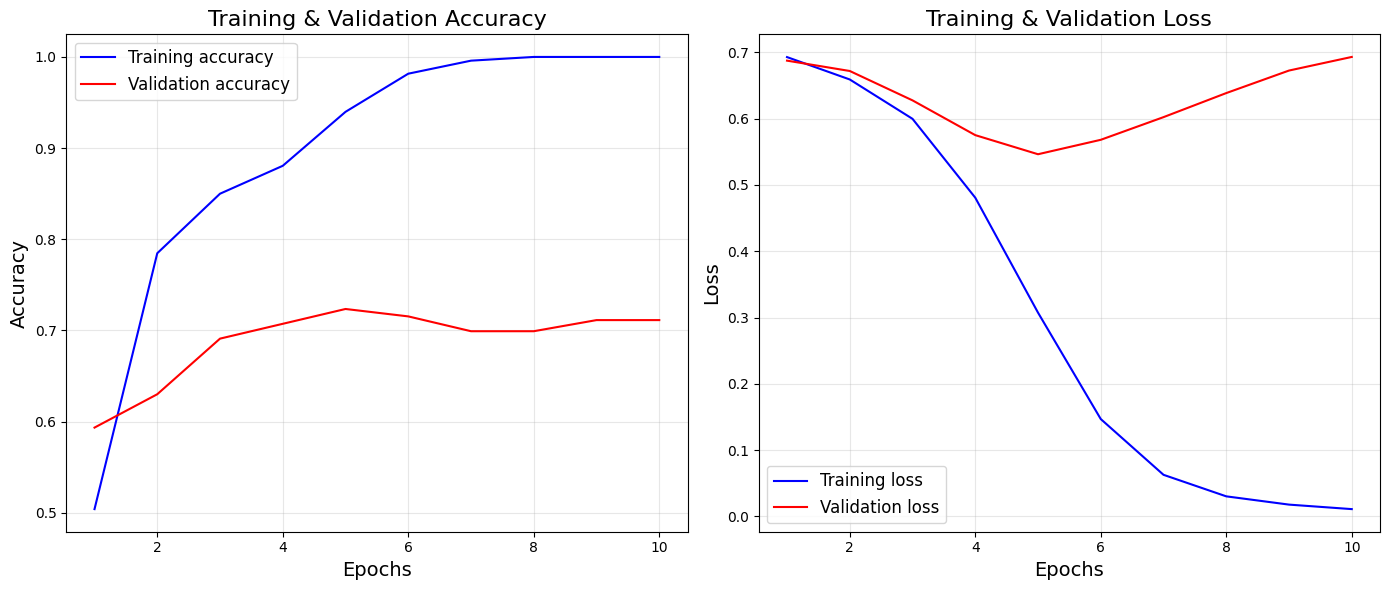

In [9]:
history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy        = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']

epochs_range = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ── Curva Accuracy vs Epochs ──────────────────────────────────────────────────
ax[0].plot(epochs_range, accuracy,     'b',   label='Training accuracy')
ax[0].plot(epochs_range, val_accuracy, 'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=14)
ax[0].set_ylabel('Accuracy', fontsize=14)
ax[0].legend(fontsize=12)
ax[0].grid(True, alpha=0.3)

# ── Curva Loss vs Epochs ──────────────────────────────────────────────────────
ax[1].plot(epochs_range, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs_range, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=14)
ax[1].set_ylabel('Loss', fontsize=14)
ax[1].legend(fontsize=12)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8 — Evaluación e inferencia

Evaluamos el modelo en el conjunto de validación y probamos con tweets de ejemplo.

In [10]:
# Evaluación final en validación
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Loss en validación   : {val_loss:.4f}")
print(f"Accuracy en validación: {val_acc:.4f}")

# ── Inferencia sobre tweets nuevos ───────────────────────────────────────────
nuevos_tweets = [
    "¡Qué día tan maravilloso, me siento genial!",
    "Estoy muy frustrado, todo salió mal hoy.",
    "El servicio fue increíble, volvería sin duda."
]

# Aplicamos el mismo preprocesamiento usando el vocabulario ya construido
nuevas_secuencias, _ = prepare(nuevos_tweets, vocab_size=vocab_size, max_length=max_length)
X_nuevo = np.array(nuevas_secuencias)

# model.predict devuelve probabilidades (valores entre 0 y 1)
predicciones = model.predict(X_nuevo, verbose=0)

print("\n── Predicciones ────────────────────────────────────")
for tweet, prob in zip(nuevos_tweets, predicciones):
    sentimiento = "POSITIVO" if prob[0] >= 0.5 else "NEGATIVO"
    print(f"Tweet     : {tweet}")
    print(f"Prob. pos.: {prob[0]:.4f}  →  {sentimiento}")
    print("─" * 55)

Loss en validación   : 0.6931
Accuracy en validación: 0.7114

── Predicciones ────────────────────────────────────
Tweet     : ¡Qué día tan maravilloso, me siento genial!
Prob. pos.: 0.0665  →  NEGATIVO 😞
───────────────────────────────────────────────────────
Tweet     : Estoy muy frustrado, todo salió mal hoy.
Prob. pos.: 0.3745  →  NEGATIVO 😞
───────────────────────────────────────────────────────
Tweet     : El servicio fue increíble, volvería sin duda.
Prob. pos.: 0.9279  →  POSITIVO 😊
───────────────────────────────────────────────────────
